In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

1) shape: (400, 600) dtype: uint8


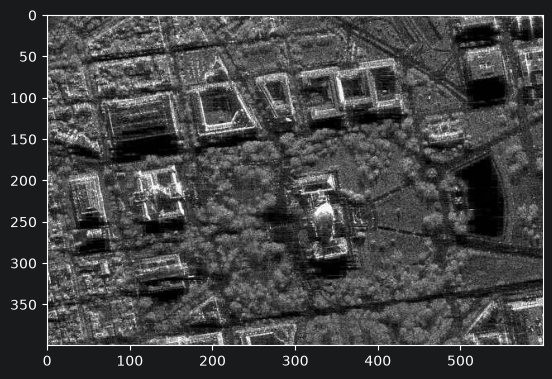

In [2]:
# 1) Загрузка фото
image = cv2.imread("sar_1_gray.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("1) shape:", image_gray.shape, "dtype:", image_gray.dtype)

plt.imshow(image_gray, cmap="gray")

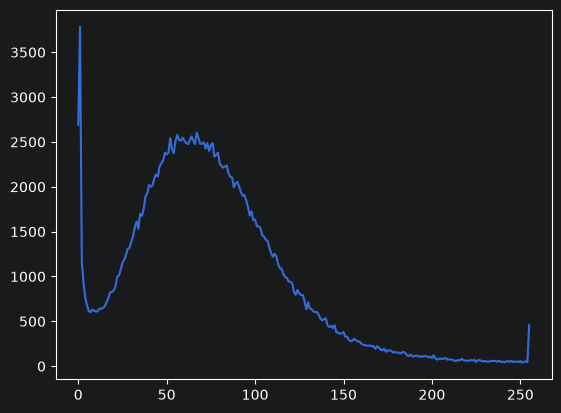

In [3]:
# 2) Гистограмма
hist = cv2.calcHist([image_gray], [0], None, [256], (0, 256), accumulate=False)

plt.plot(hist)

Text(0.5, 1.0, 'Original')

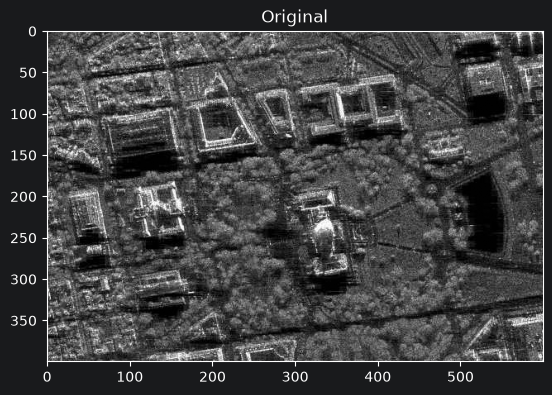

In [5]:
# 3) Алгоритм гамма коррекции
gamma_low = 0.5
gamma_high = 2.0

normalized = image_gray.astype(np.float64) / 255.0

corrected_low = np.power(normalized, gamma_low) * 255.0
corrected_low = np.clip(corrected_low, 0, 255).astype(np.uint8)

corrected_high = np.power(normalized, gamma_high) * 255.0
corrected_high = np.clip(corrected_high, 0, 255).astype(np.uint8)

plt.imshow(image_gray, cmap="gray")
plt.title("Original")

Text(0.5, 1.0, 'Gamma 0.5')

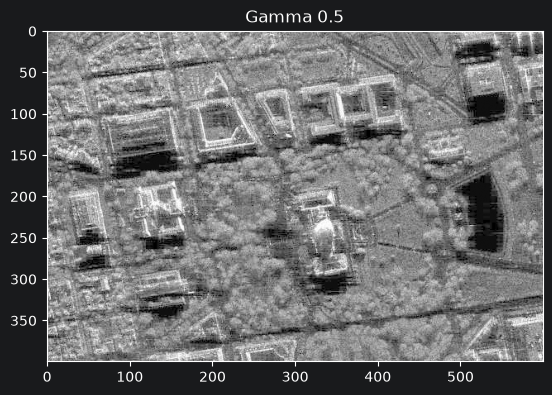

In [6]:
plt.imshow(corrected_low, cmap="gray")
plt.title("Gamma 0.5")

Text(0.5, 1.0, 'Gamma 2.0')

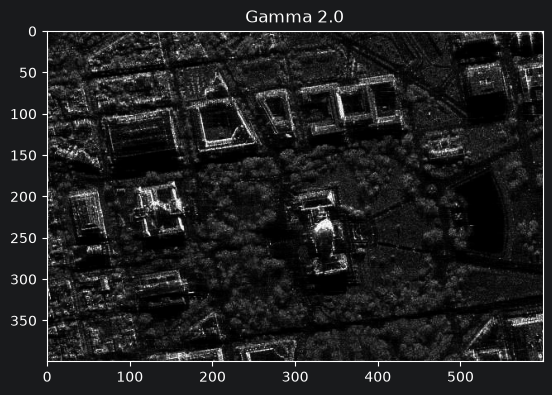

In [7]:
plt.imshow(corrected_high, cmap="gray")
plt.title("Gamma 2.0")

In [8]:
# 4) Сравнение оригинала и гамма-коррекции: MSE, SSIM
print("4) gamma =", gamma_low)
ssim_low = structural_similarity(image_gray, corrected_low)
print("SSIM: {}".format(ssim_low))
mse_low = mean_squared_error(image_gray, corrected_low)
print("MSE:", mse_low)

print("4) gamma =", gamma_high)
ssim_high = structural_similarity(image_gray, corrected_high)
print("SSIM: {}".format(ssim_high))
mse_high = mean_squared_error(image_gray, corrected_high)
print("MSE:", mse_high)

4) gamma = 0.5
SSIM: 0.7875008686792752
MSE: 3250.429145833333
4) gamma = 2.0
SSIM: 0.5270459922820343
MSE: 2383.7636375


In [9]:
# 5) Статистическая цветокоррекция на основе статистики eq_gray
hist_cum = hist.cumsum()
cdf_min = hist_cum[hist_cum > 0].min()

lut = np.round((hist_cum - cdf_min) / (image_gray.size - cdf_min) * 255)
lut = np.clip(lut, 0, 255).astype(np.uint8)
eq_gray = lut[image_gray]

mean = eq_gray.mean()
std = eq_gray.std()
print("5) eq_gray mean, std:", mean, std)

source = image_gray.astype(np.float64)

stat_corrected = (source - source.mean()) * (std / source.std()) + mean
stat_corrected = np.clip(stat_corrected, 0, 255).astype(np.uint8)

print("5) original mean, std:", image_gray.mean(), image_gray.std())
print("5) corrected mean, std:", stat_corrected.mean(), stat_corrected.std())

5) eq_gray mean, std: 127.02563333333333 74.26964841889017
5) original mean, std: 74.94157083333333 43.658465466227916
5) corrected mean, std: 123.1181375 65.3025763098039


Text(0.5, 1.0, 'Original')

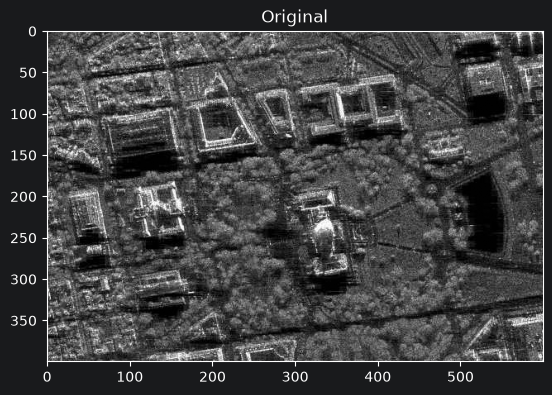

In [10]:
plt.imshow(image_gray, cmap="gray")
plt.title("Original")

Text(0.5, 1.0, 'Equalized')

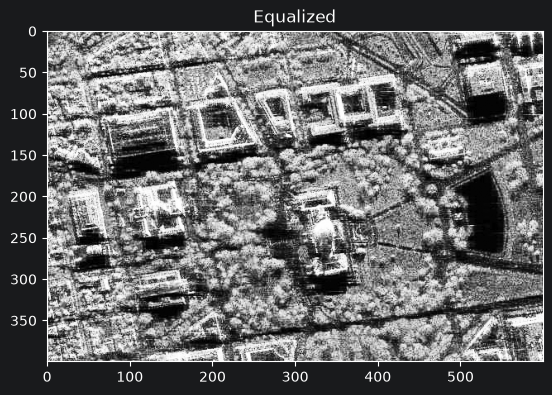

In [11]:
plt.imshow(eq_gray, cmap="gray")
plt.title("Equalized")

Text(0.5, 1.0, 'Statistically corrected')

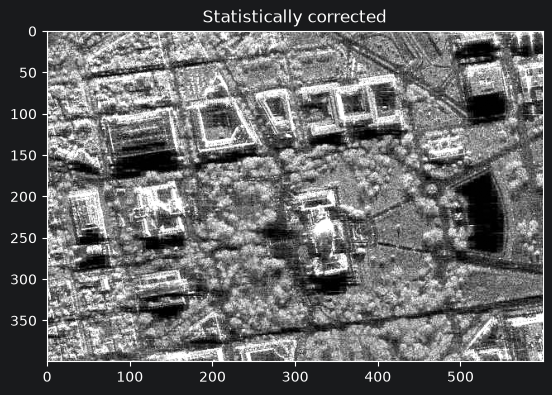

In [12]:
plt.imshow(stat_corrected, cmap="gray")
plt.title("Statistically corrected")

6) type = BINARY threshold = 80 nonzero fraction = 0.39602916666666665
6) type = BINARY_INV threshold = 80 nonzero fraction = 0.6039708333333333
6) type = TRUNC threshold = 80 nonzero fraction = 0.9887958333333333
6) type = TOZERO threshold = 80 nonzero fraction = 0.39602916666666665
6) type = TOZERO_INV threshold = 80 nonzero fraction = 0.5927666666666667
6) type = BINARY threshold = 128 nonzero fraction = 0.10112916666666667
6) type = BINARY_INV threshold = 128 nonzero fraction = 0.8988708333333333
6) type = TRUNC threshold = 128 nonzero fraction = 0.9887958333333333
6) type = TOZERO threshold = 128 nonzero fraction = 0.10112916666666667
6) type = TOZERO_INV threshold = 128 nonzero fraction = 0.8876666666666667
6) type = BINARY threshold = 180 nonzero fraction = 0.025983333333333334
6) type = BINARY_INV threshold = 180 nonzero fraction = 0.9740166666666666
6) type = TRUNC threshold = 180 nonzero fraction = 0.9887958333333333
6) type = TOZERO threshold = 180 nonzero fraction = 0.02598

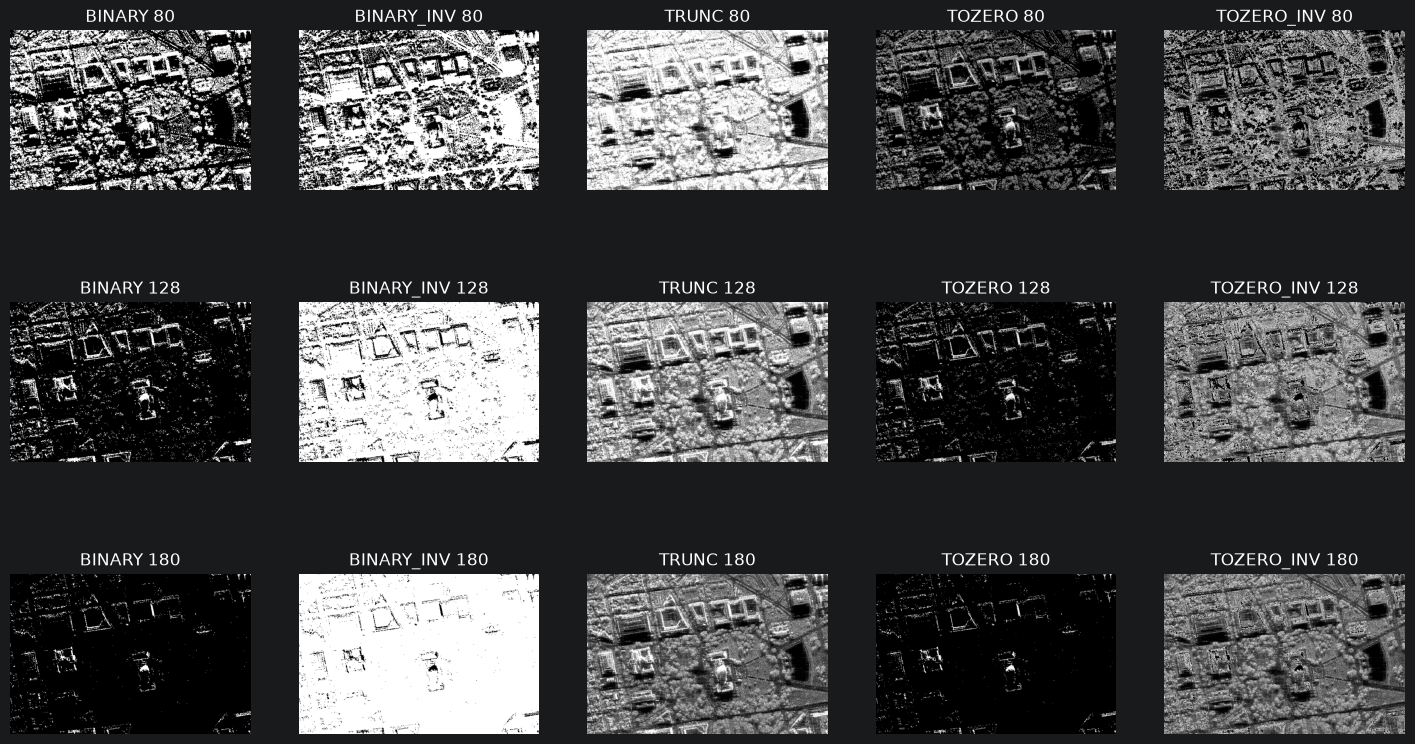

In [13]:
# 6) Пороговая фильтрация с разными параметрами
threshold_values = [80, 128, 180]
threshold_names = ["BINARY", "BINARY_INV", "TRUNC", "TOZERO", "TOZERO_INV"]
threshold_flags = [cv2.THRESH_BINARY, cv2.THRESH_BINARY_INV, cv2.THRESH_TRUNC, cv2.THRESH_TOZERO, cv2.THRESH_TOZERO_INV]

_, axes = plt.subplots(len(threshold_values), len(threshold_names), figsize=(18, 10))

for row in range(len(threshold_values)):
    t_val = threshold_values[row]
    for col in range(len(threshold_names)):
        t_name = threshold_names[col]
        t_flag = threshold_flags[col]
        _, result = cv2.threshold(image_gray, t_val, 255, t_flag)
        nonzero_fraction = np.count_nonzero(result) / result.size
        print("6) type =", t_name, "threshold =", t_val, "nonzero fraction =", nonzero_fraction)
        axes[row, col].imshow(result, cmap="gray")
        axes[row, col].set_title(t_name + " " + str(t_val))
        axes[row, col].axis("off")